## Checking data

In [15]:
import pandas as pd
import os

from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()

True

In [ ]:
# Create connection engine
engine = create_engine(
    os.environ.get("DATABASE_URL")
)

In [39]:
# Load all silver_listings into a dataframe
df_silver = pd.read_sql("SELECT * FROM silver_listings;", engine)

print(f"Loaded {len(df_silver)} rows")
df_silver.head()

Loaded 10653 rows


,id,bronze_id,price_eur,surface_m2,price_per_m2,arrondissement,rooms,longitude,latitude,scraped_at
0,1,1,6503600,487.0,13354.41,75016,8,2.270879,48.864532,2026-04-03 00:48:26.270743+00:00
1,2,2,6810000,396.0,17196.97,75016,8,2.296857,48.871225,2026-04-03 00:48:26.270743+00:00
2,3,3,13300000,360.0,36944.44,75007,8,2.302702,48.861478,2026-04-03 00:48:26.270743+00:00
3,4,4,6650000,357.0,18627.45,75008,9,2.307421,48.865528,2026-04-03 00:48:26.270743+00:00
4,5,5,8588082,346.0,24821.05,75007,8,2.302600,48.859933,2026-04-03 00:48:26.270743+00:00


In [40]:
# check count and nans in each column
df_silver.info()

<class 'pandas.DataFrame'>
RangeIndex: 10653 entries, 0 to 10652
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   id              10653 non-null  int64              
 1   bronze_id       10653 non-null  int64              
 2   price_eur       10653 non-null  int64              
 3   surface_m2      10653 non-null  float64            
 4   price_per_m2    10653 non-null  float64            
 5   arrondissement  10653 non-null  str                
 6   rooms           10653 non-null  int64              
 7   longitude       10653 non-null  float64            
 8   latitude        10653 non-null  float64            
 9   scraped_at      10653 non-null  datetime64[us, UTC]
dtypes: datetime64[us, UTC](1), float64(4), int64(4), str(1)
memory usage: 832.4 KB


In [7]:
df_silver.describe()

,id,bronze_id,price_eur,surface_m2,price_per_m2
count,10653.000000,10653.000000,1.065300e+04,10653.000000,10653.000000
mean,5327.000000,5327.000000,6.005396e+05,53.869802,10554.666537
std,3075.400543,3075.400543,6.553510e+05,39.095109,4022.359364
min,1.000000,1.000000,3.000000e+04,10.000000,3000.000000
25%,2664.000000,2664.000000,2.572700e+05,28.000000,8281.250000
50%,5327.000000,5327.000000,4.100000e+05,43.000000,9838.710000
75%,7990.000000,7990.000000,6.900000e+05,68.000000,11800.000000
max,10653.000000,10653.000000,1.330000e+07,487.000000,40000.000000


<Axes: xlabel='rooms'>

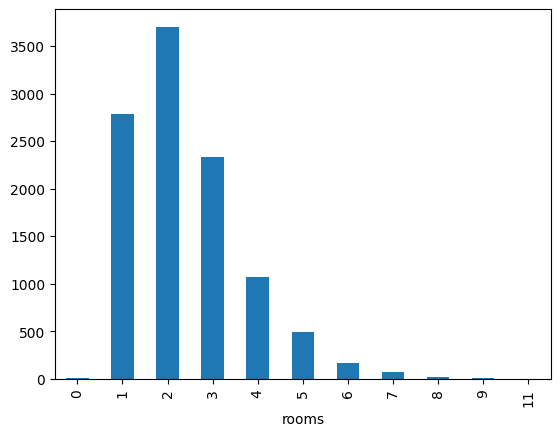

In [46]:
df_silver.rooms.value_counts(dropna=False).sort_index().plot(kind="bar")

In [ ]:
df_silver.price_eur.describe()

count    1.065300e+04
mean     6.005396e+05
std      6.553510e+05
min      3.000000e+04
25%      2.572700e+05
50%      4.100000e+05
75%      6.900000e+05
max      1.330000e+07
Name: price_eur, dtype: float64

<Axes: xlabel='rooms', ylabel='price_eur'>

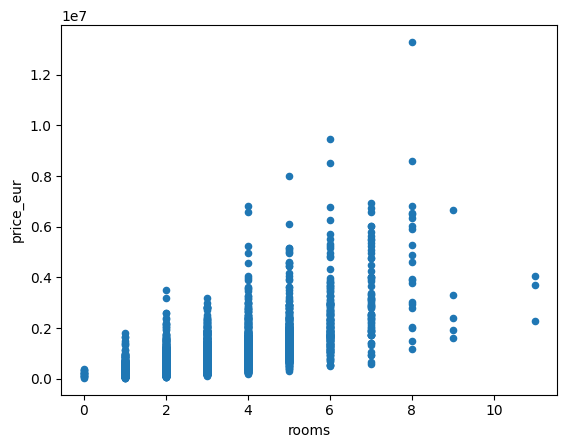

In [50]:
# Scatter plot of price vs. rooms
df_silver.plot.scatter(x="rooms", y="price_eur")

<Axes: xlabel='arrondissement', ylabel='price_eur'>

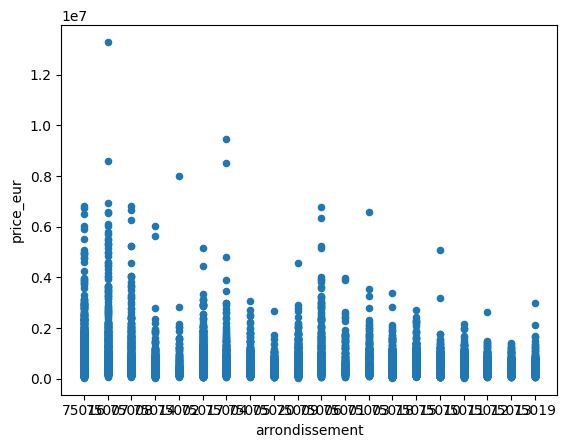

In [52]:
# Scatter plot of price vs. arrondissement
df_silver.plot.scatter(x="arrondissement", y="price_eur")

## Comparing possible models

In [54]:
import pandas as pd
import numpy as np

from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

import lightgbm as lgb

In [55]:
df = df_silver.copy()

# Target (log-transform improves stability)
y = np.log(df["price_eur"])

# Feature engineering
df["month"] = df["scraped_at"].dt.month
df["year"] = df["scraped_at"].dt.year

# Drop leakage + useless IDs
X = df.drop(columns=[
    "price_eur",
    "price_per_m2",   # leakage
    "id",
    "bronze_id",
    "scraped_at"
])


In [56]:
num_features = ["surface_m2", "rooms", "longitude", "latitude", "month", "year"]
cat_features = ["arrondissement"]

In [57]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ]
)

In [58]:
ridge_model = Pipeline([
    ("prep", preprocessor),
    ("model", Ridge(alpha=1.0))
])


In [ ]:
lgb_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ]
)
lgb_preprocessor.set_output(transform="pandas")

lgb_model = Pipeline([
    ("prep", lgb_preprocessor),
    ("model", lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42
    ))
])

In [60]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate(model, X, y):
    scores = cross_val_score(
        model,
        X,
        y,
        scoring="neg_root_mean_squared_error",
        cv=kf
    )
    return -scores.mean(), scores.std()

def evaluate_price(model, X, y):
	model.fit(X, y)
	y_pred_log = model.predict(X)
	y_pred = np.exp(y_pred_log)
	rmse = np.sqrt(mean_squared_error(np.exp(y), y_pred))
	return rmse

ridge_rmse, ridge_std = evaluate(ridge_model, X, y)
lgb_rmse, lgb_std = evaluate(lgb_model, X, y)
ridge_price_rmse = evaluate_price(ridge_model, X, y)
lgb_price_rmse = evaluate_price(lgb_model, X, y)

print(f"Ridge RMSE: {ridge_rmse:.4f} ± {ridge_std:.4f}")
print(f"LightGBM RMSE: {lgb_rmse:.4f} ± {lgb_std:.4f}")
print(f"Ridge RMSE (price): {ridge_price_rmse:.2f} EUR")
print(f"LightGBM RMSE (price): {lgb_price_rmse:.2f} EUR")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000170 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 755
[LightGBM] [Info] Number of data points in the train set: 8522, number of used features: 24
[LightGBM] [Info] Start training from score 12.983304


/Users/javierabao/Library/Caches/pypoetry/virtualenvs/model-mQZ217qp-py3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000152 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 753
[LightGBM] [Info] Number of data points in the train set: 8522, number of used features: 24
[LightGBM] [Info] Start training from score 12.974026


/Users/javierabao/Library/Caches/pypoetry/virtualenvs/model-mQZ217qp-py3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000154 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 753
[LightGBM] [Info] Number of data points in the train set: 8522, number of used features: 24
[LightGBM] [Info] Start training from score 12.981455


...

/Users/javierabao/Library/Caches/pypoetry/virtualenvs/model-mQZ217qp-py3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000183 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 753
[LightGBM] [Info] Number of data points in the train set: 8523, number of used features: 24
[LightGBM] [Info] Start training from score 12.981110


/Users/javierabao/Library/Caches/pypoetry/virtualenvs/model-mQZ217qp-py3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000153 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 10653, number of used features: 24
[LightGBM] [Info] Start training from score 12.980321
Ridge RMSE: 0.3683 ± 0.0101
LightGBM RMSE: 0.2821 ± 0.0090
Ridge RMSE (price): 2126489.86 EUR
LightGBM RMSE (price): 206362.58 EUR


/Users/javierabao/Library/Caches/pypoetry/virtualenvs/model-mQZ217qp-py3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
